Dataset Overview:
Total Rows: 205
Total Columns: 26

Column Data Types:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

First Few Rows:
   symboling normalized-losses         make fuel-type aspiration num-of-doors  \
0          3                 ?  alfa-romero       gas        s

<ipython-input-18-b7ad055bd15e>:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
<ipython-input-18-b7ad055bd15e>:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

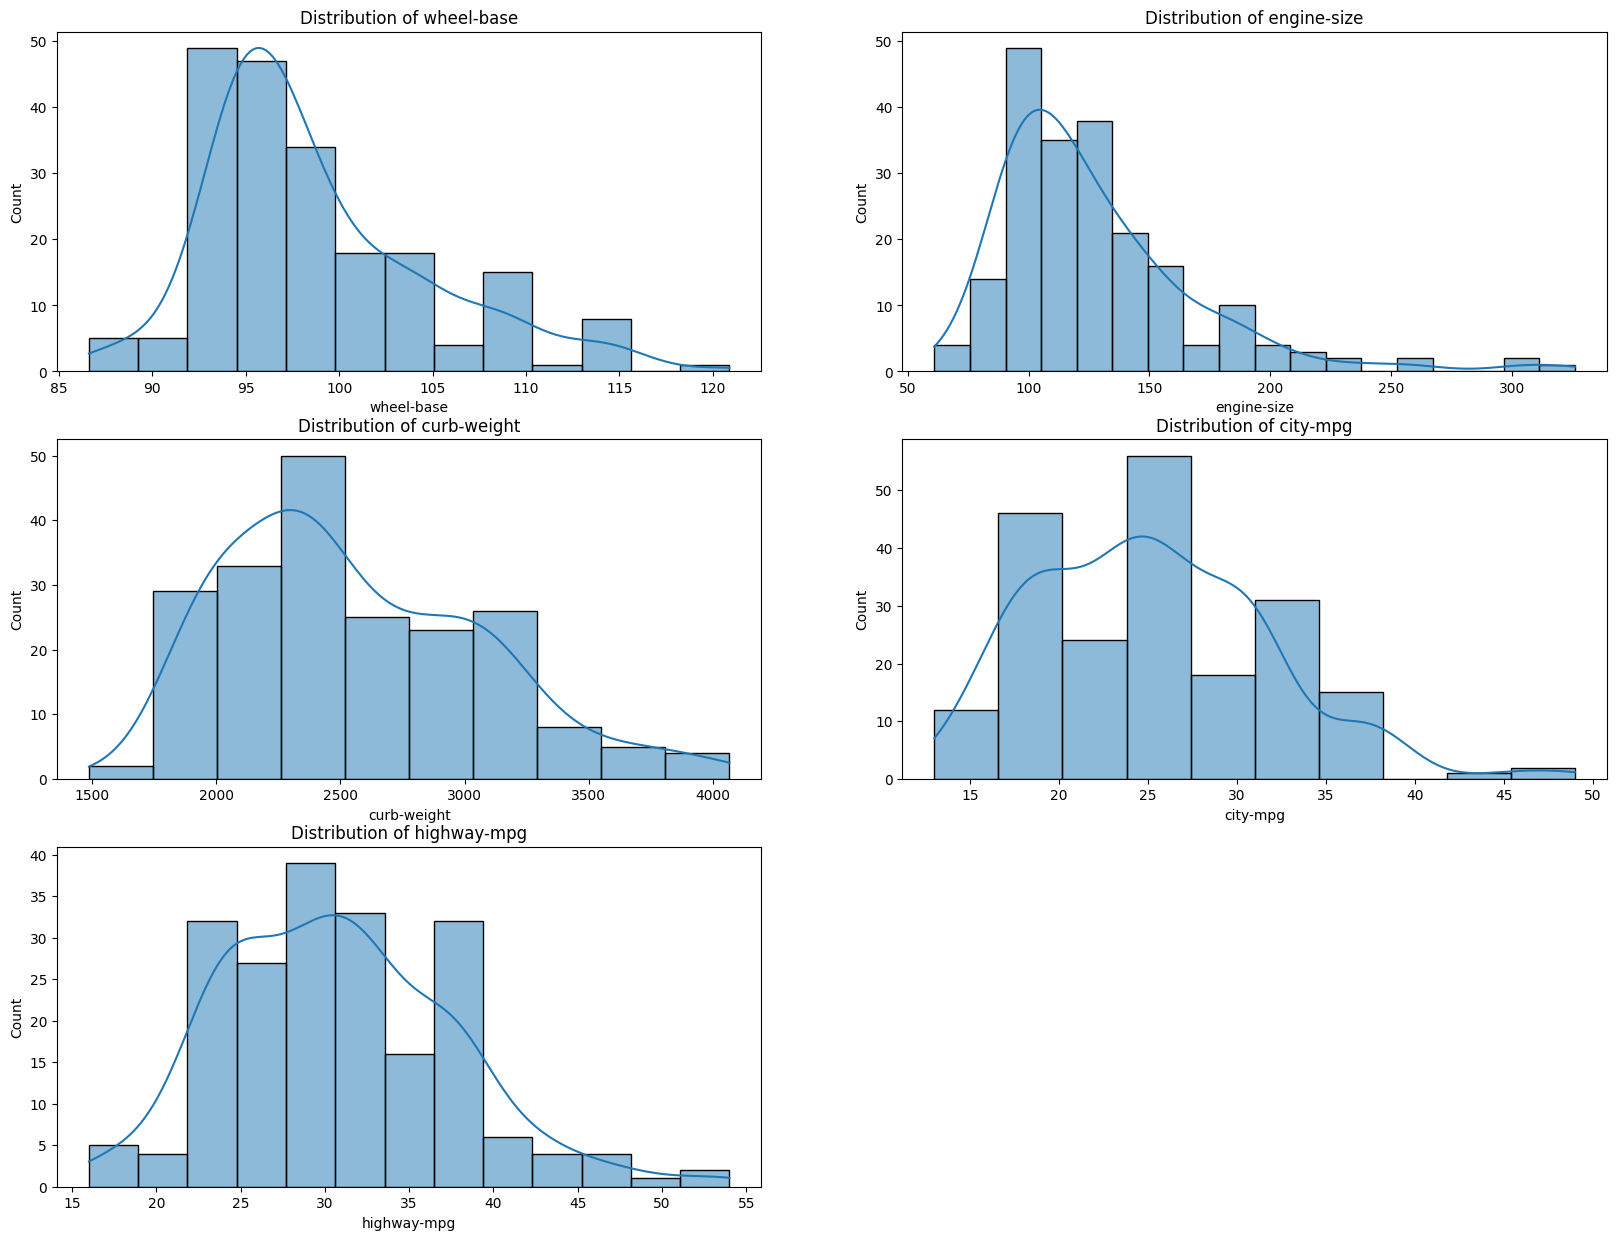

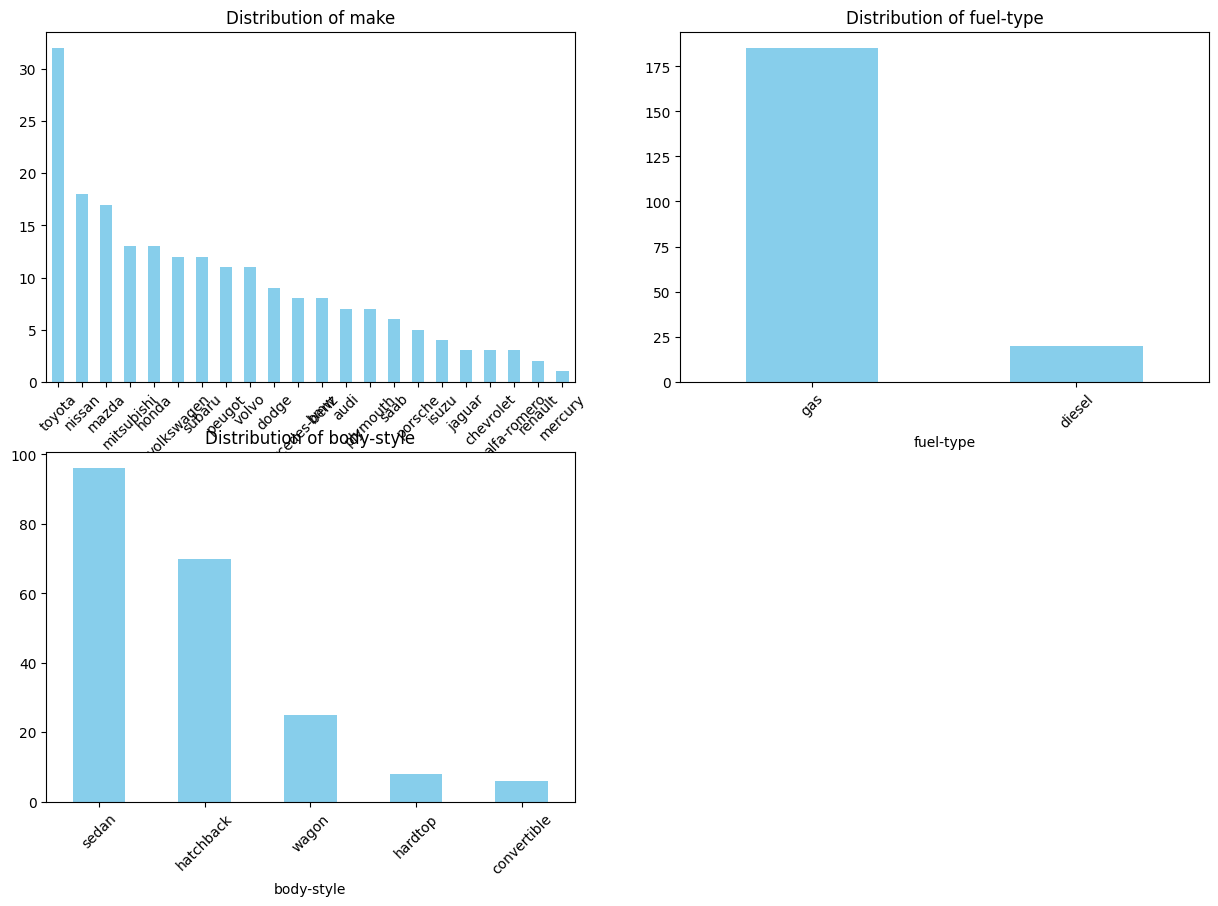

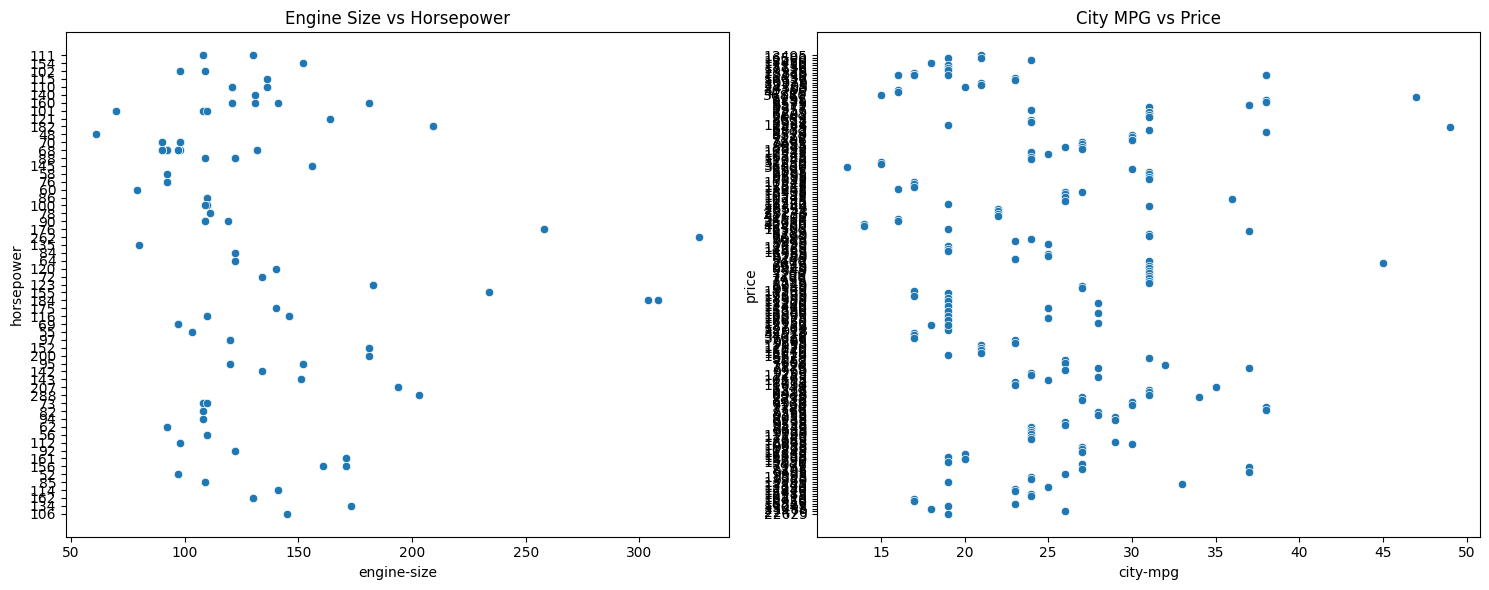


Multivariate Mean Vector:
symboling               0.834146
wheel-base             98.756585
length                174.049268
width                  65.907805
height                 53.724878
curb-weight          2555.565854
engine-size           126.907317
compression-ratio      10.142537
city-mpg               25.219512
highway-mpg            30.751220
dtype: float64

Covariance Matrix (Inner Product Method):
                    symboling   wheel-base       length       width  \
symboling            1.550789    -3.989099    -5.494240   -0.622229   
wheel-base          -3.989099    36.261782    64.975189   10.271615   
length              -5.494240    64.975189   152.208688   22.261035   
width               -0.622229    10.271615    22.261035    4.601900   
height              -1.646344     8.673144    14.802788    1.463579   
curb-weight       -147.636083  2434.296746  5638.336200  968.445072   
engine-size         -5.486035   142.766545   351.081549   65.697786   
compression-ratio

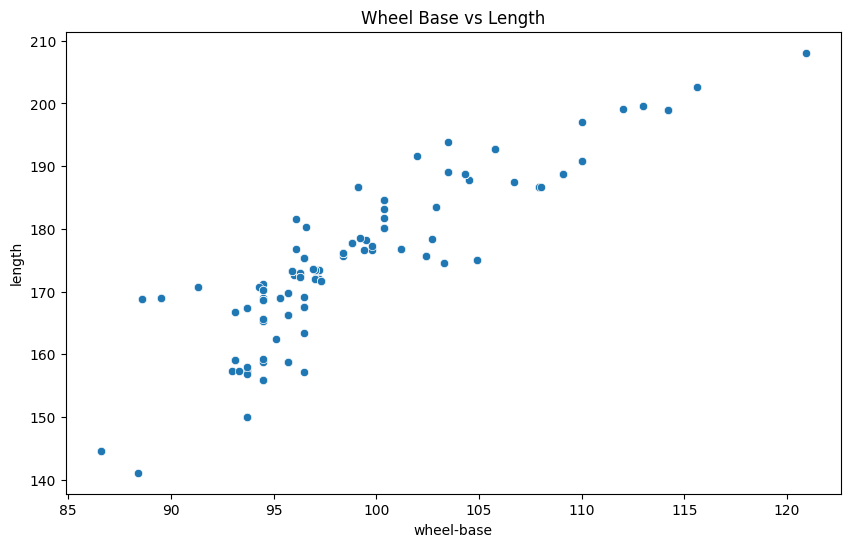


Categorical Covariance Matrix:
body-style   convertible     hardtop     hatchback         sedan          \
drive-wheels         fwd rwd     fwd rwd       4wd fwd rwd   4wd fwd rwd   
fuel-type                                                                  
diesel                 0   0       0   1         0   1   0     0   8   7   
gas                    1   5       1   6         2  48  19     3  49  29   

body-style   wagon          
drive-wheels   4wd fwd rwd  
fuel-type                   
diesel           0   0   3  
gas              4  12   6  


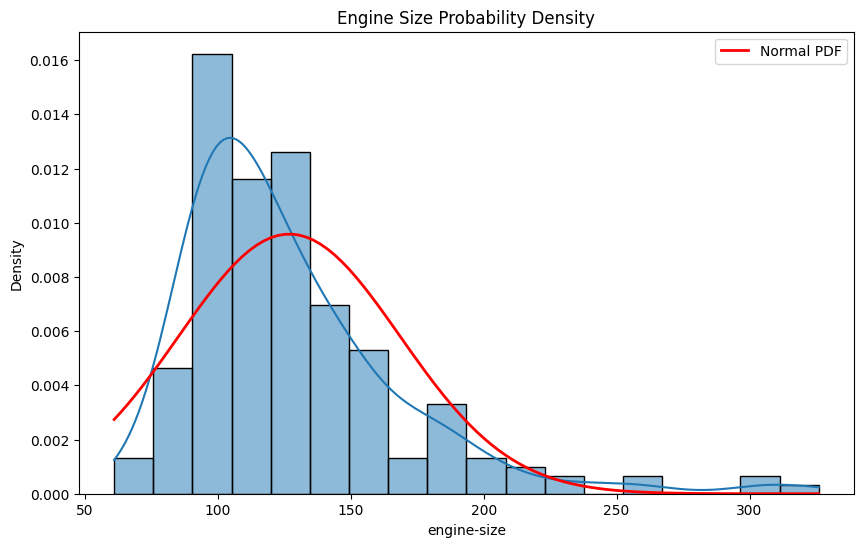


Variance Analysis:
Largest Variance: curb-weight (271107.87)
Smallest Variance: symboling (1.55)

Covariance Analysis:
Largest Covariance: ('curb-weight', 'engine-size') (18443.03)
Smallest Covariance: ('curb-weight', 'highway-mpg') (-2859.42)


In [ ]:
# Noah Russell    CAP4773
# Import our libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def load_and_analyze_data(filepath):
    """
    Load the dataset, display an overview, and summarize its structure.
    """
    try:
        # Load the dataset
        df = pd.read_csv(filepath)

        # Display dataset overview: Rows, Columns, Data Types, and First few rows
        print("Dataset Overview:")
        print(f"Total Rows: {df.shape[0]}")
        print(f"Total Columns: {df.shape[1]}")
        print("\nColumn Data Types:")
        print(df.dtypes)
        print("\nFirst Few Rows:")
        print(df.head())

        return df
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

def clean_and_preprocess_data(df):
    """
    Handle missing values and prepare the data for analysis.
    """
    # Replace '?' with NaN to handle missing data
    df.replace("?", np.nan, inplace=True)

    # Identify numeric and categorical columns
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

    # Convert numeric columns to proper numeric type and fill missing values with median
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col].fillna(df[col].median(), inplace=True)

    # Fill missing values for categorical columns with the mode (most frequent value)
    for col in categorical_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)

    return df, numeric_cols, categorical_cols

def exploratory_data_analysis(df, numeric_cols, categorical_cols):
    """
    Perform exploratory data analysis with visualizations.
    """
    # Visualize distributions of selected numeric features
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(['wheel-base', 'engine-size', 'curb-weight', 'city-mpg', 'highway-mpg'], 1):
        plt.subplot(3, 2, i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')

    # Visualize categorical columns with bar charts
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(['make', 'fuel-type', 'body-style'], 1):
        plt.subplot(2, 2, i)
        df[col].value_counts().plot(kind='bar', color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)

    # Scatter plots for relationships between numeric features
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    sns.scatterplot(data=df, x='engine-size', y='horsepower')
    plt.title('Engine Size vs Horsepower')

    plt.subplot(1, 2, 2)
    sns.scatterplot(data=df, x='city-mpg', y='price')
    plt.title('City MPG vs Price')

    plt.tight_layout()
    plt.show()

def advanced_statistical_analysis(df, numeric_cols, categorical_cols):
    """
    Perform advanced statistical analysis including covariance, correlation, and distributions.
    """
    # Calculate multivariate mean vector for numeric columns
    mean_vector = df[numeric_cols].mean()
    print("\nMultivariate Mean Vector:")
    print(mean_vector)

    # Center data by subtracting the mean vector
    centered_data = df[numeric_cols] - mean_vector

    # Covariance Matrix using Inner Product Method
    cov_matrix_inner = np.dot(centered_data.T, centered_data) / (len(df) - 1)
    cov_matrix_inner_df = pd.DataFrame(cov_matrix_inner, index=numeric_cols, columns=numeric_cols)
    print("\nCovariance Matrix (Inner Product Method):")
    print(cov_matrix_inner_df)

    # Covariance Matrix using Outer Product Method (Pandas built-in function)
    cov_matrix_outer = df[numeric_cols].cov()
    print("\nCovariance Matrix (Outer Product Method):")
    print(cov_matrix_outer)

    # Calculate and display correlation between 'wheel-base' and 'length'
    correlation = df['wheel-base'].corr(df['length'])
    print(f"\nCorrelation between 'wheel-base' and 'length': {correlation:.4f}")

    # Scatter plot for 'wheel-base' and 'length' relationship
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='wheel-base', y='length')
    plt.title('Wheel Base vs Length')
    plt.show()

    # Create a frequency matrix for categorical variables ('fuel-type', 'body-style', 'drive-wheels')
    categorical_covariance = pd.crosstab(df['fuel-type'], [df['body-style'], df['drive-wheels']])
    print("\nCategorical Covariance Matrix:")
    print(categorical_covariance)

    # Probability Density Function (PDF) for 'engine-size'
    engine_size = df['engine-size']
    plt.figure(figsize=(10, 6))
    sns.histplot(engine_size, stat='density', kde=True)

    # Overlay normal distribution on the histogram
    mu, std = engine_size.mean(), engine_size.std()
    x = np.linspace(engine_size.min(), engine_size.max(), 100)
    plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal PDF')
    plt.title('Engine Size Probability Density')
    plt.legend()
    plt.show()

    # Variance analysis to identify which features have the highest and lowest variance
    variances = df[numeric_cols].var()
    print("\nVariance Analysis:")
    print(f"Largest Variance: {variances.idxmax()} ({variances.max():.2f})")
    print(f"Smallest Variance: {variances.idxmin()} ({variances.min():.2f})")

    # Perform covariance analysis for numeric columns
    cov_matrix = df[numeric_cols].cov()
    cov_matrix_unstacked = cov_matrix.unstack()
    non_diagonal = cov_matrix_unstacked[cov_matrix_unstacked.index.get_level_values(0) !=
                                         cov_matrix_unstacked.index.get_level_values(1)]
    print("\nCovariance Analysis:")
    print(f"Largest Covariance: {non_diagonal.idxmax()} ({non_diagonal.max():.2f})")
    print(f"Smallest Covariance: {non_diagonal.idxmin()} ({non_diagonal.min():.2f})")

def main():
    filepath = "Automobile_data.csv"  # Update with the correct path

    # Load and analyze data
    df = load_and_analyze_data(filepath)

    if df is not None:
        # Clean and preprocess the data
        df, numeric_cols, categorical_cols = clean_and_preprocess_data(df)

        # Perform exploratory data analysis (EDA)
        exploratory_data_analysis(df, numeric_cols, categorical_cols)

        # Perform advanced statistical analysis
        advanced_statistical_analysis(df, numeric_cols, categorical_cols)

if __name__ == "__main__":
    main()

